## Train LSTM (Next-action classification)

- Input: `data/data_user500.csv` (user_id, product_id, action, timestamp)
- Task: dự đoán **hành vi kế tiếp** (8 lớp)
- Output:
  - `ml/artifacts/lstm/model_lstm.keras`
  - `ml/artifacts/lstm/results.json`
  - `ml/artifacts/lstm/label_map.json`
  - `ml/artifacts/lstm/plots/lstm_curves.png`, `lstm_confusion.png`

Chạy lần lượt các cell (hoặc Run All).

In [1]:
# Nếu thiếu thư viện, chạy 1 lần:
# !pip install -r ml/requirements.txt

import json
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split

import tensorflow as tf

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


def find_repo_root() -> Path:
    """Find repo root by locating data/data_user500.csv walking up from cwd."""
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / 'data' / 'data_user500.csv').exists():
            return p
    guess = here
    if guess.name.lower() == 'ml':
        guess = guess.parent
    return guess


ROOT = find_repo_root()
DATA_CSV = ROOT / 'data' / 'data_user500.csv'
OUT_DIR = ROOT / 'ml' / 'artifacts' / 'lstm'
PLOTS_DIR = OUT_DIR / 'plots'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print('TensorFlow:', tf.__version__)
print('cwd:', Path.cwd().resolve())
print('ROOT:', ROOT)
print('CSV exists:', DATA_CSV.exists(), DATA_CSV)
print('OUT_DIR:', OUT_DIR.resolve())

if not DATA_CSV.exists():
    raise FileNotFoundError(
        f"Cannot find CSV at {DATA_CSV}. "
        "Make sure you open this notebook inside the SAD-134 project folder."
    )

TensorFlow: 2.21.0
cwd: C:\SAD-134\ml
ROOT: C:\SAD-134
CSV exists: True C:\SAD-134\data\data_user500.csv
OUT_DIR: C:\SAD-134\ml\artifacts\lstm


In [2]:
BEHAVIORS_8 = [
    'view',
    'click',
    'add_to_cart',
    'purchase',
    'search',
    'browse_products',
    'browse_recommended',
    'checkout',
]

label_to_id = {b: i for i, b in enumerate(BEHAVIORS_8)}
id_to_label = {i: b for b, i in label_to_id.items()}


def load_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    needed = {'user_id', 'product_id', 'action', 'timestamp'}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f'CSV missing columns: {sorted(missing)}')

    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce', utc=True)
    df = df.dropna(subset=['user_id', 'action', 'timestamp']).copy()
    df['user_id'] = df['user_id'].astype(str)
    df['action'] = df['action'].astype(str)
    df = df[df['action'].isin(label_to_id.keys())].copy()
    df = df.sort_values(['user_id', 'timestamp'], ascending=True)
    df['label_id'] = df['action'].map(label_to_id).astype(int)
    return df


df = load_csv(DATA_CSV)
print('rows:', len(df))
print('users:', df['user_id'].nunique())
print('action_counts:', df['action'].value_counts().to_dict())

rows: 30056
users: 500
action_counts: {'view': 9922, 'click': 6055, 'add_to_cart': 3640, 'search': 2978, 'checkout': 2145, 'browse_recommended': 2092, 'browse_products': 1625, 'purchase': 1599}


In [3]:
# B22DCCN416 Nguyen Tuan Hung
@dataclass(frozen=True)
class Dataset:
    x_train: np.ndarray
    y_train: np.ndarray
    x_val: np.ndarray
    y_val: np.ndarray
    x_test: np.ndarray
    y_test: np.ndarray


def build_next_action_dataset(df: pd.DataFrame, *, seq_len: int, seed: int) -> Dataset:
    users = df['user_id'].drop_duplicates().tolist()
    u_train, u_tmp = train_test_split(users, test_size=0.30, random_state=seed, shuffle=True)
    u_val, u_test = train_test_split(u_tmp, test_size=0.50, random_state=seed, shuffle=True)

    def to_xy(uids):
        x_list, y_list = [], []
        sub = df[df['user_id'].isin(uids)]
        for _, g in sub.groupby('user_id', sort=False):
            seq = g['label_id'].tolist()
            if len(seq) <= seq_len:
                continue
            for i in range(seq_len, len(seq)):
                x_list.append(seq[i-seq_len:i])
                y_list.append(seq[i])
        return np.asarray(x_list, dtype=np.int32), np.asarray(y_list, dtype=np.int32)

    x_train, y_train = to_xy(set(u_train))
    x_val, y_val = to_xy(set(u_val))
    x_test, y_test = to_xy(set(u_test))

    print('x_train:', x_train.shape, 'x_val:', x_val.shape, 'x_test:', x_test.shape)
    assert x_train.shape[0] > 1000, 'Not enough training samples. Increase events per user or reduce seq_len.'
    return Dataset(x_train, y_train, x_val, y_val, x_test, y_test)


SEQ_LEN = 6
EMBED_DIM = 32
RNN_UNITS = 128
EPOCHS = 20
BATCH_SIZE = 256

ds = build_next_action_dataset(df, seq_len=SEQ_LEN, seed=SEED)

x_train: (18923, 6) x_val: (4009, 6) x_test: (4124, 6)


In [4]:
# B22DCCN416 Nguyen Tuan Hung
def build_lstm_model():
    inputs = tf.keras.Input(shape=(SEQ_LEN,), dtype='int32')
    x = tf.keras.layers.Embedding(input_dim=len(BEHAVIORS_8), output_dim=EMBED_DIM, name='action_embedding')(inputs)
    x = tf.keras.layers.LSTM(RNN_UNITS, name='lstm')(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(len(BEHAVIORS_8), activation='softmax')(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name='lstm_next_action')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    return model


model = build_lstm_model()
model.summary()

Model: "lstm_next_action"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 6)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ action_embedding (Embedding)         │ (None, 6, 32)               │             256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 128)                 │          82,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             520 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 91,464 (357.28 KB)

 Trainable params: 91,464 (357.28 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# B22DCCN416 Nguyen Tuan Hung
best_path = OUT_DIR / 'model_best_lstm.keras'

# Handle class imbalance (rare actions) via class weights.
counts = np.bincount(ds.y_train, minlength=len(BEHAVIORS_8)).astype(np.float64)
counts = np.maximum(counts, 1.0)
inv = 1.0 / counts
class_weight = {i: float(inv[i] / inv.mean()) for i in range(len(BEHAVIORS_8))}
print('class_weight:', class_weight)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=best_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
    ),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-5),
]

history = model.fit(
    ds.x_train,
    ds.y_train,
    validation_data=(ds.x_val, ds.y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2,
    callbacks=callbacks,
    class_weight=class_weight,
)

probs = model.predict(ds.x_test, batch_size=512, verbose=0)
y_pred = probs.argmax(axis=1).astype(np.int32)

acc = float(accuracy_score(ds.y_test, y_pred))
macro_f1 = float(f1_score(ds.y_test, y_pred, average='macro'))
print('accuracy:', acc)
print('macro_f1:', macro_f1)

print('\nClassification report (test):')
print(classification_report(ds.y_test, y_pred, target_names=[id_to_label[i] for i in range(len(BEHAVIORS_8))], digits=4))

print('Best checkpoint (by val_loss):', best_path)

class_weight: {0: 0.24099882652533083, 1: 0.4095351680481129, 2: 0.7143659685626194, 3: 1.3655904043753364, 4: 0.917816730721688, 5: 1.9407528653314512, 6: 1.072034916087849, 7: 1.3389051203476112}
Epoch 1/20
74/74 - 2s - 32ms/step - accuracy: 0.4091 - loss: 1.1392 - val_accuracy: 0.4193 - val_loss: 1.4404 - learning_rate: 0.0010
Epoch 2/20
74/74 - 1s - 11ms/step - accuracy: 0.4298 - loss: 0.7869 - val_accuracy: 0.4470 - val_loss: 1.3372 - learning_rate: 0.0010
Epoch 3/20
74/74 - 1s - 11ms/step - accuracy: 0.4419 - loss: 0.7595 - val_accuracy: 0.4799 - val_loss: 1.2936 - learning_rate: 0.0010
Epoch 4/20
74/74 - 1s - 11ms/step - accuracy: 0.4460 - loss: 0.7493 - val_accuracy: 0.5071 - val_loss: 1.2566 - learning_rate: 0.0010
Epoch 5/20
74/74 - 1s - 10ms/step - accuracy: 0.4518 - loss: 0.7423 - val_accuracy: 0.4727 - val_loss: 1.2679 - learning_rate: 0.0010
Epoch 6/20
74/74 - 1s - 10ms/step - accuracy: 0.4566 - loss: 0.7370 - val_accuracy: 0.4532 - val_loss: 1.2620 - learning_rate: 5.000

C:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

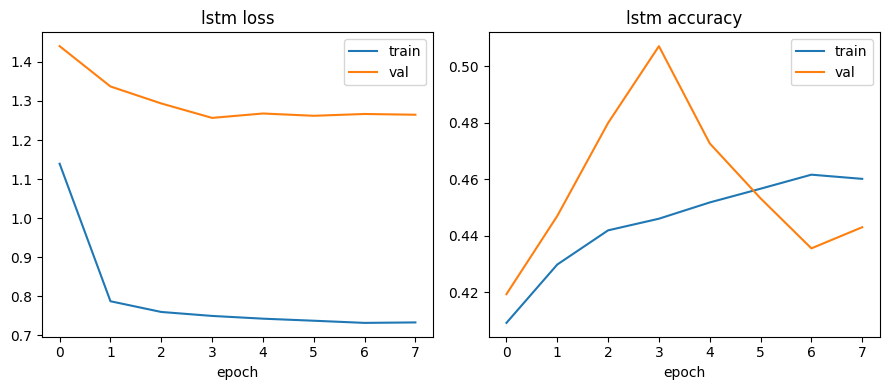

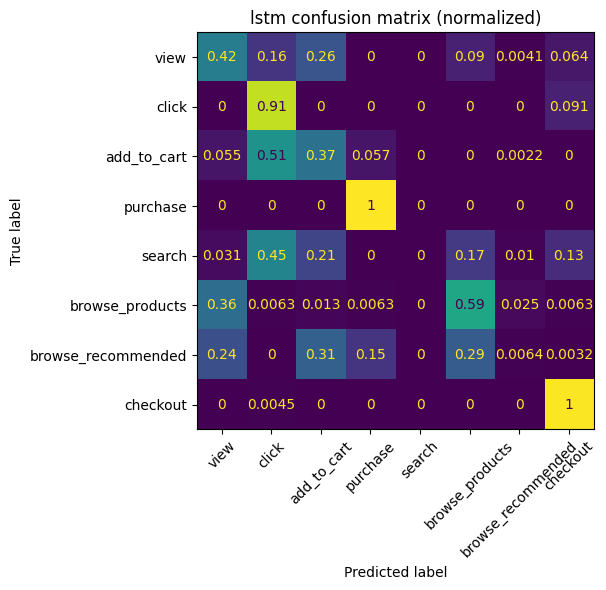

Saved plots: C:\SAD-134\ml\artifacts\lstm\plots\lstm_curves.png C:\SAD-134\ml\artifacts\lstm\plots\lstm_confusion.png


In [6]:
# Plots

plt.figure(figsize=(9, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history.get('loss', []), label='train')
plt.plot(history.history.get('val_loss', []), label='val')
plt.title('lstm loss')
plt.xlabel('epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history.get('accuracy', []), label='train')
plt.plot(history.history.get('val_accuracy', []), label='val')
plt.title('lstm accuracy')
plt.xlabel('epoch')
plt.legend()

plt.tight_layout()
curve_path = PLOTS_DIR / 'lstm_curves.png'
plt.savefig(curve_path, dpi=150)
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    ds.y_test,
    y_pred,
    display_labels=[id_to_label[i] for i in range(len(BEHAVIORS_8))],
    xticks_rotation=45,
    colorbar=False,
    normalize='true',
    ax=ax,
)
ax.set_title('lstm confusion matrix (normalized)')
fig.tight_layout()
conf_path = PLOTS_DIR / 'lstm_confusion.png'
fig.savefig(conf_path, dpi=150)
plt.show()
plt.close(fig)

print('Saved plots:', curve_path, conf_path)

In [7]:
# Save artifacts
meta = {
    'task': 'next_action_prediction',
    'model_kind': 'lstm',
    'label_space': BEHAVIORS_8,
    'seq_len': int(SEQ_LEN),
    'embed_dim': int(EMBED_DIM),
    'rnn_units': int(RNN_UNITS),
    'epochs': int(EPOCHS),
    'batch_size': int(BATCH_SIZE),
    'seed': int(SEED),
    'metrics': {'accuracy': acc, 'macro_f1': macro_f1},
    'selection_note': 'Use macro_f1 when comparing models because class distribution is imbalanced.',
}

(OUT_DIR / 'results.json').write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding='utf-8')
(OUT_DIR / 'label_map.json').write_text(json.dumps(label_to_id, ensure_ascii=False, indent=2), encoding='utf-8')

model_path = OUT_DIR / 'model_lstm.keras'
model.save(model_path)

print('Saved:', model_path)
print(json.dumps(meta, ensure_ascii=False, indent=2))

Saved: C:\SAD-134\ml\artifacts\lstm\model_lstm.keras
{
  "task": "next_action_prediction",
  "model_kind": "lstm",
  "label_space": [
    "view",
    "click",
    "add_to_cart",
    "purchase",
    "search",
    "browse_products",
    "browse_recommended",
    "checkout"
  ],
  "seq_len": 6,
  "embed_dim": 32,
  "rnn_units": 128,
  "epochs": 20,
  "batch_size": 256,
  "seed": 42,
  "metrics": {
    "accuracy": 0.5181862269641125,
    "macro_f1": 0.4247764013239887
  },
  "selection_note": "Use macro_f1 when comparing models because class distribution is imbalanced."
}
